Import data

In [ ]:
import pandas as pd
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
pk_data = pd.read_excel('./PKData_Publication.xlsx')

In [ ]:
PARAMS_DF = pd.read_excel('./PKParams_Publication.xlsx')

In [ ]:
TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

In [ ]:
def get_infusion_rate(t, dose_mg):
    dose_ng = dose_mg * 1_000_000
    if 0 <= t <= 1.91:
        return (dose_ng * 0.91) / 1.91
    elif 1.91 < t <= 2.0:
        return (dose_ng * 0.09) / 0.09
    else:
        return 0.0

In [ ]:
def pk_model(t, y, dose_mg, p, R=get_infusion_rate):
    A1, A2, A3, A1T, A2T, A3T, A4T = y

    R_in = R(t, dose_mg)

    ddt_A1  = p['k1tp']*A1T - (p['k1pt'] + p['k12'] + p['kcl1'])*A1 + R_in
    ddt_A2  = p['k12']*A1 + p['k2tp']*A2T - (p['k2pt'] + p['kcl2'] + p['k23'])*A2
    ddt_A3  = p['k3tp']*A3T - (p['kcl3'] + p['k3pt'])*A3 + p['k23']*A2

    ddt_A1T = p['k1pt']*A1 - p['k1tp']*A1T - p['k12']*A1T
    ddt_A2T = p['k2pt']*A2 + p['k12']*A1T - p['k23']*A2T - p['k2tp']*A2T

    ddt_A3T = (
        -p['k3tp']*A3T
        + p['k23']*A2T
        + p['k3pt']*A3
        - p['k34']*A3T
    )

    ddt_A4T =  p['k34']*A3T - p['kcl4']*A4T

    return [
        ddt_A1,
        ddt_A2,
        ddt_A3,
        ddt_A1T,
        ddt_A2T,
        ddt_A3T,
        ddt_A4T
    ]

Plot concentration over time

In [ ]:
def simulate_dose(dose_mg, t_span=(0, 150), num_points=2000):
    t_eval = np.linspace(t_span[0], t_span[1], num_points)

    y0 = [0, 0, 0, 0, 0, 0, 0]

    p_row = PARAMS_DF[PARAMS_DF['id'] == dose_mg].iloc[0]

    solution = solve_ivp(
        fun=pk_model,
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        args=(dose_mg, p_row),
        method='LSODA'
    )

    A1, A2, A3, A1T, A2T, A3T, A4T = solution.y

    # Concentrations
    CRDV    = A1 / p_row['V1']
    C704277 = A2 / p_row['V2']
    C441524 = A3 / p_row['V3']

    # Calculate concentration for A4T
    C443902 = A4T / p_row['V4T']

    return solution.t, CRDV, C704277, C441524, C443902

In [ ]:
def plot_pk_accuracy(pk_data):
    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': SMALL_SIZE,
        'ytick.labelsize': SMALL_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'figure.titlesize': MEDIUM_SIZE,
        'legend.fontsize': TINY_SIZE,
        'axes.titleweight': 'normal',
        'figure.titleweight': 'normal'
    })

    target_doses = [3, 10, 30, 75, 150, 225]

    color_map = {
        3:   'tab:purple', 10:  'tab:cyan', 30:  'tab:green',
        75:  'crimson', 150: 'darkorange', 225: 'navy'
    }

    fig, axes = plt.subplots(2, 2, figsize=(4.58, 4.12), dpi=300)

    ax = axes.flatten()

    for dose in target_doses:
        color = color_map[dose]
        t_sim, c_A1, c_A2, c_A3, c_A4 = simulate_dose(
            dose,
            t_span=(0, 150),
            num_points=2000
        )

        ax[0].plot(t_sim, c_A1, color=color, linewidth=1, label=f'{dose} mg')
        ax[1].plot(t_sim, c_A2, color=color, linewidth=1, label=f'{dose} mg')
        ax[2].plot(t_sim, c_A3, color=color, linewidth=1, label=f'{dose} mg')

        df_a1 = pk_data[(pk_data['Drug'] == 'RDV') & (pk_data['Dose'] == dose)]
        if not df_a1.empty:
            ax[0].scatter(df_a1['Time(hr)'], df_a1['Concentration(ng/ml)'],
                          color=color, marker='o', s=8, edgecolor='black', alpha=0.75, zorder=5, linewidth=0.3)

        df_a2 = pk_data[(pk_data['Drug'] == 'GS704277') & (pk_data['Dose'] == dose)]
        if not df_a2.empty:
            ax[1].scatter(df_a2['Time(hr)'], df_a2['Concentration(ng/ml)'],
                          color=color, marker='^', s=8, edgecolor='black', alpha=0.75, zorder=5, linewidth=0.3)

        df_a3 = pk_data[(pk_data['Drug'] == 'GS441524') & (pk_data['Dose'] == dose)]
        if not df_a3.empty:
            ax[2].scatter(df_a3['Time(hr)'], df_a3['Concentration(ng/ml)'],
                          color=color, marker='s', s=8, edgecolor='black', alpha=0.75, zorder=5, linewidth=0.3)

        if dose == 150:
            t_sim_150, c_A1_150, c_A2_150, c_A3_150, C443902_150 = simulate_dose(
                150,
                t_span=(0, 150),
                num_points=2000
            )

            ax[3].plot(
                t_sim_150, c_A1_150,
                color='navy', linewidth=1.0, label='A1'
            )

            ax[3].plot(
                t_sim_150, c_A2_150,
                color='firebrick', linewidth=1.0, label='A2'
            )

            ax[3].plot(
                t_sim_150, c_A3_150,
                color='darkgreen', linewidth=1.0, label='A3'
            )

            ax[3].plot(
                t_sim_150,
                C443902_150,
                color='orange',
                linewidth=1.0,
                label='A4T'
            )

    # Panel 0: A1 (Labeled 'I')
    ax[0].set_xlim(0, 5)
    ax[0].set_yscale('log')
    ax[0].set_ylim(bottom=10**-1)
    ax[0].set_xlabel('Time (hours)')
    ax[0].set_ylabel('Concentration\n(ng/mL)')
    ax[0].set_title('I. GS-5734 (A1)', loc='left')
    ax[0].grid(True, alpha=0.3, which="both", ls="--")

    # Panel 1: A2 (Labeled 'II')
    ax[1].set_xlim(0, 15)
    ax[1].set_yscale('log')
    ax[1].set_ylim(bottom=10**-1)
    ax[1].set_xlabel('Time (hours)')
    ax[1].set_title('II. GS-704277 (A2)', loc='left')
    ax[1].grid(True, alpha=0.3, which="both", ls="--")

    # Panel 2: A3 (Labeled 'III')
    ax[2].set_xlim(0, 150)
    ax[2].set_yscale('log')
    ax[2].set_ylim(bottom=10**-1)
    ax[2].set_xlabel('Time (hours)')
    ax[2].set_ylabel('Concentration\n(ng/mL)')
    ax[2].set_title('III. GS-441524 (A3)', loc='left')
    ax[2].grid(True, alpha=0.3, which="both", ls="--")

    # Panel 3: Combined 150mg Cascade (Labeled 'IV')
    ax[3].set_xlim(0, 150)
    ax[3].set_yscale('log')
    ax[3].set_ylim(bottom=10**-1, top=10**3.7)
    ax[3].set_xlabel('Time (hours)')
    ax[3].set_ylabel('Concentration\n(ng/mL)') # Added y-label so panel 4 matches units
    ax[3].set_title('IV. Multi-Compartment (150mg)', loc='left')
    ax[3].grid(True, alpha=0.3, which="both", ls="--")

    # Legends
    handles_doses, labels_doses = ax[1].get_legend_handles_labels()
    ax[1].legend(
        handles_doses,
        labels_doses,
        loc='upper right',
        bbox_to_anchor=(1.2, 1.07),
        framealpha=0.9,
        frameon=True,
        edgecolor='black'
    )

    handles1, labels1 = ax[3].get_legend_handles_labels()
    ax[3].legend(
        handles1,
        labels1,
        loc='upper right',
        frameon=True,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.show()

    plt.rcdefaults()

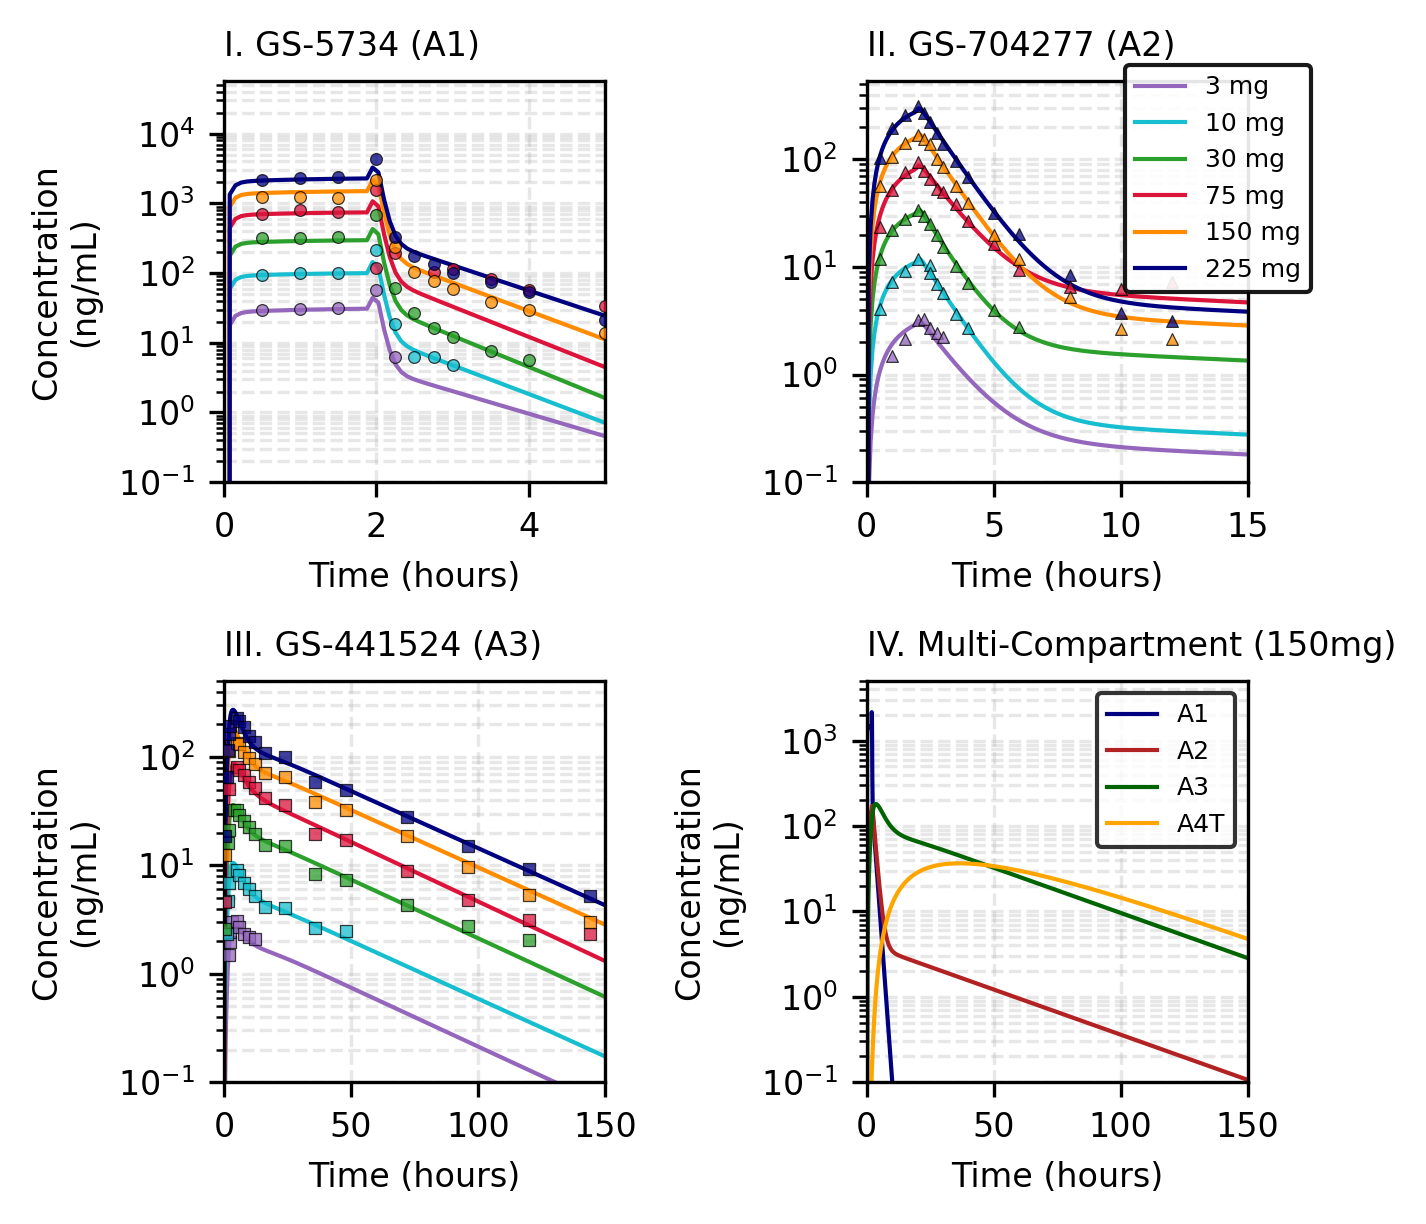

In [ ]:
plot_pk_accuracy(pk_data)